#Import Libraries

In [ ]:
import requests
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Data Collection

In [ ]:
import requests
import pandas as pd

lat = 30.0444
lon = 31.2357
start = "2018-01-01"
end = "2026-04-01"

aq_params = "pm10,pm2_5,nitrogen_dioxide"
weather_params = "temperature_2m,relative_humidity_2m,wind_speed_10m,precipitation"

aq_url = f"https://air-quality-api.open-meteo.com/v1/air-quality?latitude={lat}&longitude={lon}&hourly={aq_params}&start_date={start}&end_date={end}&timezone=Africa/Cairo"
weather_url = f"https://archive-api.open-meteo.com/v1/archive?latitude={lat}&longitude={lon}&start_date={start}&end_date={end}&hourly={weather_params}&timezone=Africa/Cairo"

print("Fetching essential data from APIs (Cairo Timezone)...")

aq_res = requests.get(aq_url).json()
w_res = requests.get(weather_url).json()

df_aq = pd.DataFrame(aq_res['hourly'])
df_w = pd.DataFrame(w_res['hourly'])

df = pd.merge(df_aq, df_w, on="time")

df.to_csv("cairo_clean_data.csv", index=False)
print("Done! Data is now aligned with Cairo local time.")
print(df.head())

Fetching essential data from APIs (Cairo Timezone)...
Done! Data is now aligned with Cairo local time.
               time  pm10  pm2_5  nitrogen_dioxide  temperature_2m  \
0  2018-01-01T00:00  54.2   12.4               1.8            11.8   
1  2018-01-01T01:00  46.5   11.6               1.9            11.4   
2  2018-01-01T02:00  34.6    8.4               1.6            11.6   
3  2018-01-01T03:00  28.8   26.7               2.3            11.9   
4  2018-01-01T04:00  48.8   44.8              11.6            11.7   

   relative_humidity_2m  wind_speed_10m  precipitation  
0                    63            15.5            0.0  
1                    63            15.7            0.0  
2                    61            16.1            0.0  
3                    62            18.2            0.0  
4                    68            18.1            0.0  


In [ ]:
len(df)

72312

# Data Preprocessing & Cleaning

In [ ]:
print("Dataset Shape:", df.shape)
df.info()

Dataset Shape: (72312, 8)
<class 'pandas.DataFrame'>
RangeIndex: 72312 entries, 0 to 72311
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   time                  72312 non-null  str    
 1   pm10                  72312 non-null  float64
 2   pm2_5                 72312 non-null  float64
 3   nitrogen_dioxide      72312 non-null  float64
 4   temperature_2m        72312 non-null  float64
 5   relative_humidity_2m  72312 non-null  int64  
 6   wind_speed_10m        72312 non-null  float64
 7   precipitation         72312 non-null  float64
dtypes: float64(6), int64(1), str(1)
memory usage: 5.5 MB


In [ ]:
df.isnull().sum()

time                    0
pm10                    0
pm2_5                   0
nitrogen_dioxide        0
temperature_2m          0
relative_humidity_2m    0
wind_speed_10m          0
precipitation           0
dtype: int64

In [ ]:
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicates: 0


# Feature Engineering

In [ ]:
# Create Target: AQI Classification based on PM2.5 (Standard EPA thresholds)
def get_aqi_class(pm25):
    if pm25 <= 12.0:
        return "Good"
    elif pm25 <= 35.4:
        return "Moderate"
    else:
        return "Poor"

df['AQI_Class'] = df['pm2_5'].apply(get_aqi_class)

print("Class counts:")
print(df['AQI_Class'].value_counts())

Class counts:
AQI_Class
Moderate    52795
Poor        17162
Good         2355
Name: count, dtype: int64


In [ ]:
df.head()


,time,pm10,pm2_5,nitrogen_dioxide,temperature_2m,relative_humidity_2m,wind_speed_10m,precipitation,AQI_Class
0,2018-01-01T00:00,54.2,12.4,1.8,11.8,63,15.5,0.0,Moderate
1,2018-01-01T01:00,46.5,11.6,1.9,11.4,63,15.7,0.0,Good
2,2018-01-01T02:00,34.6,8.4,1.6,11.6,61,16.1,0.0,Good
3,2018-01-01T03:00,28.8,26.7,2.3,11.9,62,18.2,0.0,Moderate
4,2018-01-01T04:00,48.8,44.8,11.6,11.7,68,18.1,0.0,Poor


In [ ]:
df["AQI_Class"].value_counts()

AQI_Class
Moderate    52795
Poor        17162
Good         2355
Name: count, dtype: int64

In [ ]:
# 1. Convert time column to datetime objects (if not already done)
df['time'] = pd.to_datetime(df['time'])

# 2. Extract specific features
df['year'] = df['time'].dt.year
df['day_of_week'] = df['time'].dt.dayofweek # For Modeling (0=Monday, 6=Sunday)

# 3. Create a Weekend flag (Useful for Cairo traffic patterns)
# 4 is Friday, 5 is Saturday in Egypt
df['is_weekend'] = df['day_of_week'].isin([4, 5]).astype(int)

# 4. Check the result
print(df[['time', 'day_of_week', 'is_weekend']].head())

                 time  day_of_week  is_weekend
0 2018-01-01 00:00:00            0           0
1 2018-01-01 01:00:00            0           0
2 2018-01-01 02:00:00            0           0
3 2018-01-01 03:00:00            0           0
4 2018-01-01 04:00:00            0           0


In [ ]:
df.head()

,time,pm10,pm2_5,nitrogen_dioxide,temperature_2m,relative_humidity_2m,wind_speed_10m,precipitation,AQI_Class,year,day_of_week,is_weekend
0,2018-01-01 00:00:00,54.2,12.4,1.8,11.8,63,15.5,0.0,Moderate,2018,0,0
1,2018-01-01 01:00:00,46.5,11.6,1.9,11.4,63,15.7,0.0,Good,2018,0,0
2,2018-01-01 02:00:00,34.6,8.4,1.6,11.6,61,16.1,0.0,Good,2018,0,0
3,2018-01-01 03:00:00,28.8,26.7,2.3,11.9,62,18.2,0.0,Moderate,2018,0,0
4,2018-01-01 04:00:00,48.8,44.8,11.6,11.7,68,18.1,0.0,Poor,2018,0,0


# EDA


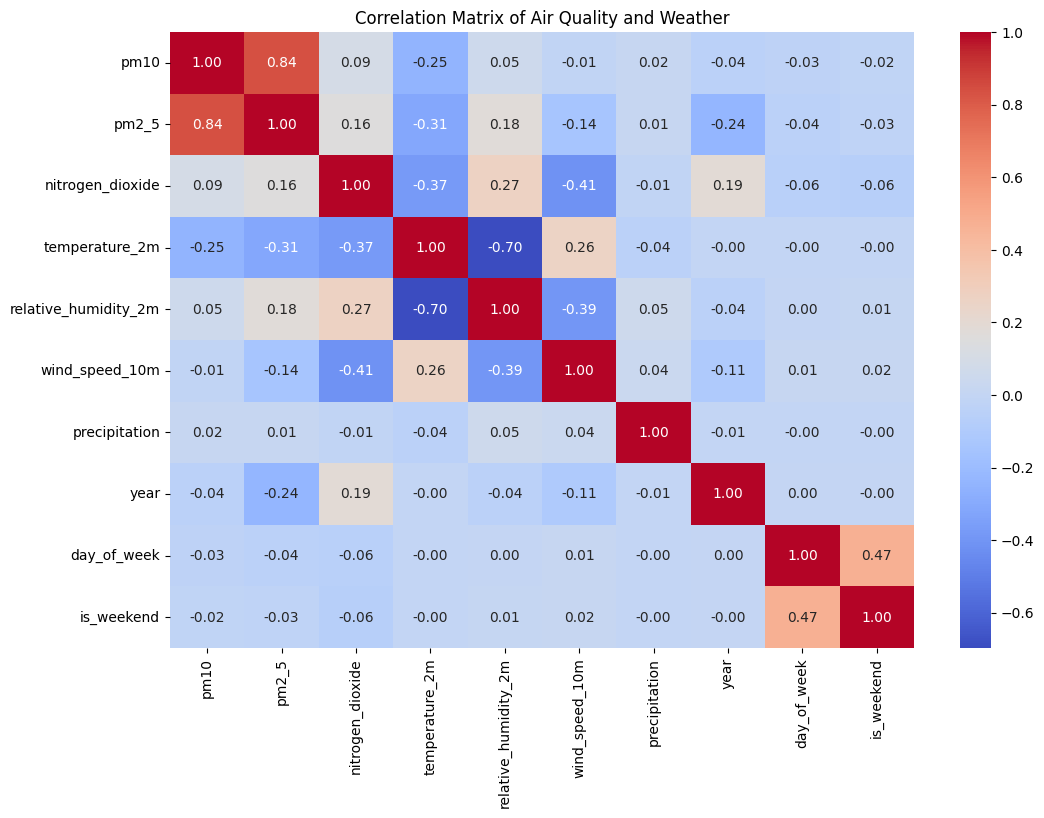

In [ ]:
plt.figure(figsize=(12, 8))
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Air Quality and Weather')
plt.show()

C:\Users\farag\AppData\Local\Temp\ipykernel_19324\3449003614.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='is_weekend', y='pm2_5', data=df, palette='Set2')


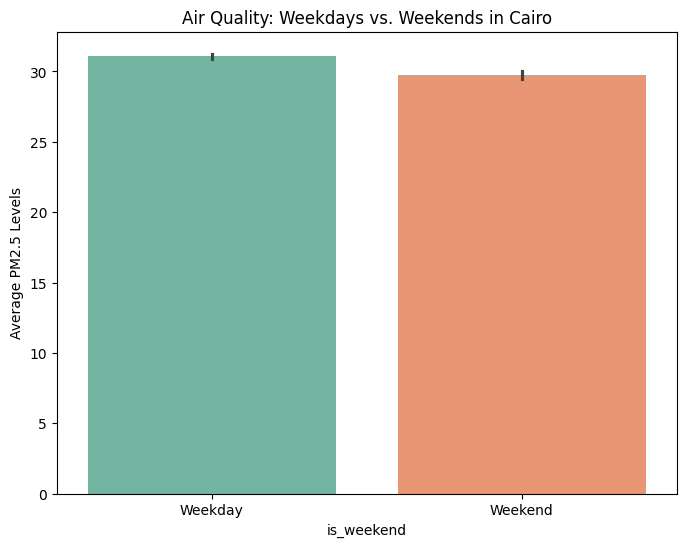

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(x='is_weekend', y='pm2_5', data=df, palette='Set2')
plt.xticks([0, 1], ['Weekday', 'Weekend'])
plt.title('Air Quality: Weekdays vs. Weekends in Cairo')
plt.ylabel('Average PM2.5 Levels')
plt.show()

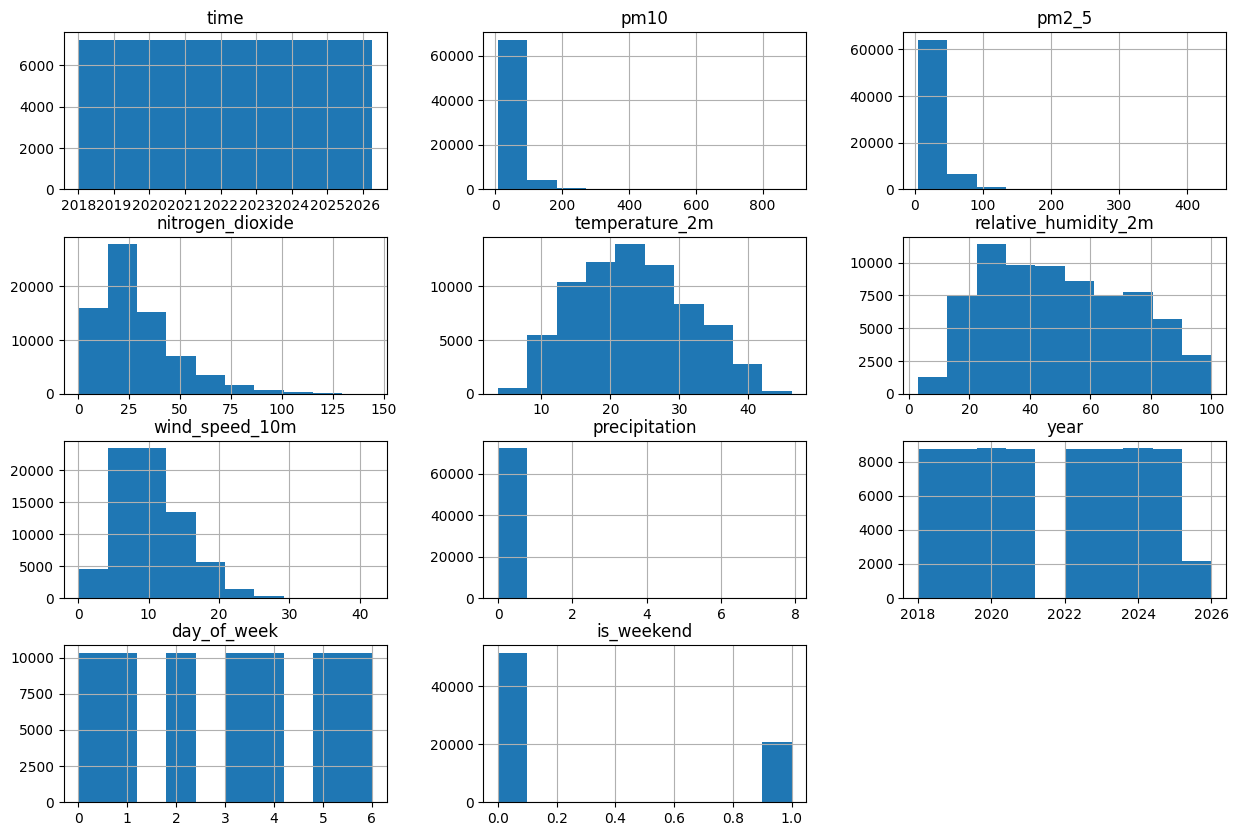

In [ ]:
df.hist(figsize=(15,10))
plt.show()

C:\Users\farag\AppData\Local\Temp\ipykernel_19324\2984946319.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='AQI_Class', data=df, palette='viridis', order=['Good', 'Moderate', 'Poor'])


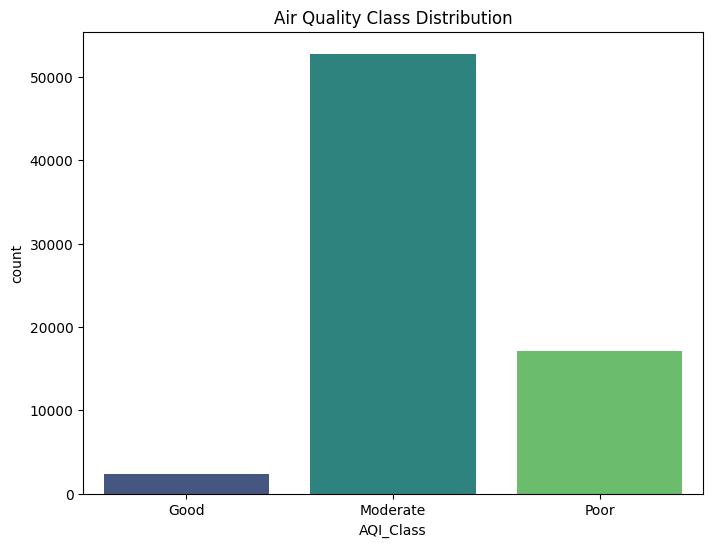

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='AQI_Class', data=df, palette='viridis', order=['Good', 'Moderate', 'Poor'])
plt.title('Air Quality Class Distribution')
plt.show()

In [ ]:
df=df.drop(columns=['pm2_5', 'time', 'day_of_week'])

In [ ]:
df.head()

,pm10,nitrogen_dioxide,temperature_2m,relative_humidity_2m,wind_speed_10m,precipitation,AQI_Class,year,is_weekend
0,54.2,1.8,11.8,63,15.5,0.0,Moderate,2018,0
1,46.5,1.9,11.4,63,15.7,0.0,Good,2018,0
2,34.6,1.6,11.6,61,16.1,0.0,Good,2018,0
3,28.8,2.3,11.9,62,18.2,0.0,Moderate,2018,0
4,48.8,11.6,11.7,68,18.1,0.0,Poor,2018,0


# Data Preprocessing and Class Balancing (SMOTE)

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import numpy as np

# 1. Label Encoding for the Target (Convert Good/Moderate/Poor to numerical values)
le = LabelEncoder()
df['AQI_Class'] = le.fit_transform(df['AQI_Class'])

# 2. Define Features (X) and Target (y)
X = df.drop(columns=['AQI_Class'])
y = df['AQI_Class']

# 3. Split the data into Training and Testing sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Feature Scaling (Standardize features by removing the mean and scaling to unit variance)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Handle Class Imbalance using SMOTE (Oversampling the minority classes)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("Data Preprocessing Completed Successfully!")
print(f"Training set shape after SMOTE: {X_train_res.shape}")

Data Preprocessing Completed Successfully!
Training set shape after SMOTE: (126726, 8)


# Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# 1. Initialize and train the Logistic Regression model
# We use max_iter=1000 to ensure convergence on the resampled data
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_res, y_train_res)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [ ]:
# 2. Make predictions on the scaled test set
y_pred_lr = lr_model.predict(X_test_scaled)

In [ ]:
# 3. Calculate Accuracies
lr_train_acc = lr_model.score(X_train_res, y_train_res)
lr_test_acc = lr_model.score(X_test_scaled, y_test)

In [ ]:
# 4. Print Metrics
print("--- Logistic Regression ---")
print(f"Training Accuracy: {lr_train_acc:.4f}")
print(f"Testing Accuracy: {lr_test_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

--- Logistic Regression ---
Training Accuracy: 0.8831
Testing Accuracy: 0.8289

Classification Report:
              precision    recall  f1-score   support

        Good       0.30      0.91      0.45       476
    Moderate       0.95      0.81      0.87     10553
        Poor       0.75      0.89      0.81      3434

    accuracy                           0.83     14463
   macro avg       0.67      0.87      0.71     14463
weighted avg       0.88      0.83      0.84     14463



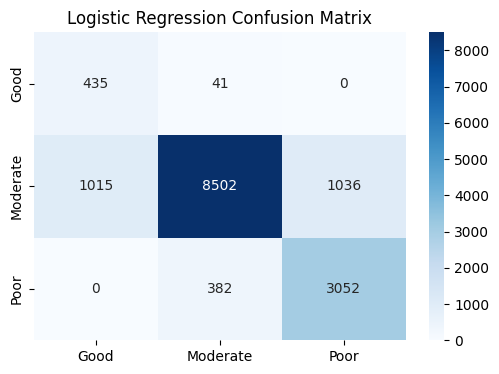

In [ ]:
# 5. Visualize
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Logistic Regression Confusion Matrix')
plt.show()

# KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
# 1. Initialize and train the k-NN model
# Setting n_neighbors=10 is a standard starting point for classification
knn_model = KNeighborsClassifier(n_neighbors=10)
knn_model.fit(X_train_res, y_train_res)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",10
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [ ]:
# 2. Make predictions
y_pred_knn = knn_model.predict(X_test_scaled)

In [ ]:
# 3. Calculate Accuracies
knn_train_acc = knn_model.score(X_train_res, y_train_res)
knn_test_acc = knn_model.score(X_test_scaled, y_test)

In [ ]:
# 4. Print Metrics
print("--- k-Nearest Neighbors ---")
print(f"Training Accuracy: {knn_train_acc:.4f}")
print(f"Testing Accuracy: {knn_test_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn, target_names=le.classes_))

--- k-Nearest Neighbors ---
Training Accuracy: 0.9445
Testing Accuracy: 0.8479

Classification Report:
              precision    recall  f1-score   support

        Good       0.31      0.86      0.45       476
    Moderate       0.96      0.83      0.89     10553
        Poor       0.78      0.90      0.83      3434

    accuracy                           0.85     14463
   macro avg       0.68      0.86      0.73     14463
weighted avg       0.89      0.85      0.86     14463



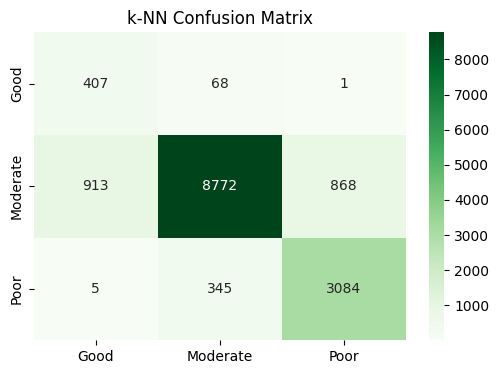

In [ ]:
# 5. Visualize
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('k-NN Confusion Matrix')
plt.show()

# SVM

In [ ]:
from sklearn.svm import SVC

# 1. Initialize and train the SVM model
# Using RBF kernel to handle potential non-linear relationships
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_res, y_train_res)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [ ]:
# 2. Make predictions
y_pred_svm = svm_model.predict(X_test_scaled)

In [ ]:
# 3. Calculate Accuracies
svm_train_acc = svm_model.score(X_train_res, y_train_res)
svm_test_acc = svm_model.score(X_test_scaled, y_test)

In [ ]:
# 4. Print Metrics
print("--- Support Vector Machine ---")
print(f"Training Accuracy: {svm_train_acc:.4f}")
print(f"Testing Accuracy: {svm_test_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

--- Support Vector Machine ---
Training Accuracy: 0.9169
Testing Accuracy: 0.8538

Classification Report:
              precision    recall  f1-score   support

        Good       0.32      0.93      0.48       476
    Moderate       0.97      0.82      0.89     10553
        Poor       0.78      0.93      0.85      3434

    accuracy                           0.85     14463
   macro avg       0.69      0.90      0.74     14463
weighted avg       0.90      0.85      0.87     14463



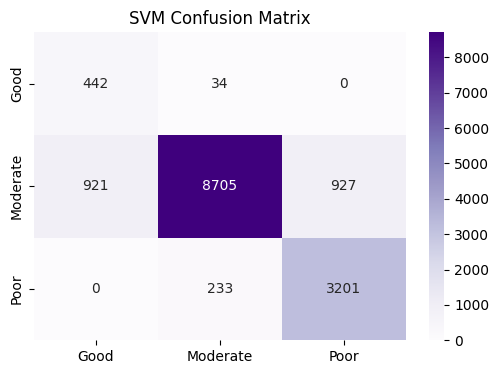

In [ ]:
# 5. Visualize
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('SVM Confusion Matrix')
plt.show()

# Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
# 1. Initialize and train the Decision Tree model
dt_model = DecisionTreeClassifier(max_depth=8, random_state=42)
dt_model.fit(X_train_res, y_train_res)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [ ]:
# 2. Make predictions
y_pred_dt = dt_model.predict(X_test_scaled)

In [ ]:
# 3. Calculate Accuracies
dt_train_acc = dt_model.score(X_train_res, y_train_res)
dt_test_acc = dt_model.score(X_test_scaled, y_test)

In [ ]:
# 4. Print Metrics
print("--- Decision Tree ---")
print(f"Training Accuracy: {dt_train_acc:.4f}")
print(f"Testing Accuracy: {dt_test_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, target_names=le.classes_))

--- Decision Tree ---
Training Accuracy: 0.9151
Testing Accuracy: 0.8480

Classification Report:
              precision    recall  f1-score   support

        Good       0.32      0.89      0.47       476
    Moderate       0.97      0.82      0.89     10553
        Poor       0.76      0.93      0.84      3434

    accuracy                           0.85     14463
   macro avg       0.68      0.88      0.73     14463
weighted avg       0.90      0.85      0.86     14463



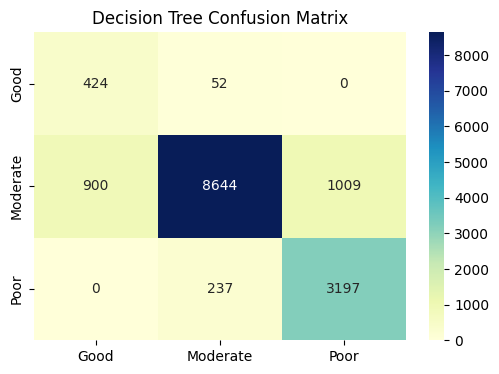

In [ ]:
# 5. Visualize
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Decision Tree Confusion Matrix')
plt.show()

# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Initialize the Random Forest Classifier
# n_estimators=100: Using 100 different decision trees to build the forest
# random_state=42: Ensuring reproducibility of results
rf_model = RandomForestClassifier(n_estimators=100, max_depth=12, min_samples_split=10, random_state=42)

In [ ]:
# 2. Train the model using the resampled (SMOTE) training data
rf_model.fit(X_train_res, y_train_res)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [ ]:
# 3. Calculate Accuracies
y_pred_rf = rf_model.predict(X_test_scaled)
rf_train_acc = rf_model.score(X_train_res, y_train_res)
rf_test_acc = rf_model.score(X_test_scaled, y_test)

In [ ]:
# 4. Print Metrics
print("--- Random Forest Classifier ---")
print(f"Training Accuracy: {rf_train_acc:.4f}")
print(f"Testing Accuracy: {rf_test_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

--- Random Forest Classifier ---
Training Accuracy: 0.9484
Testing Accuracy: 0.8787

Classification Report:
              precision    recall  f1-score   support

        Good       0.42      0.90      0.57       476
    Moderate       0.97      0.86      0.91     10553
        Poor       0.78      0.94      0.85      3434

    accuracy                           0.88     14463
   macro avg       0.72      0.90      0.78     14463
weighted avg       0.91      0.88      0.89     14463



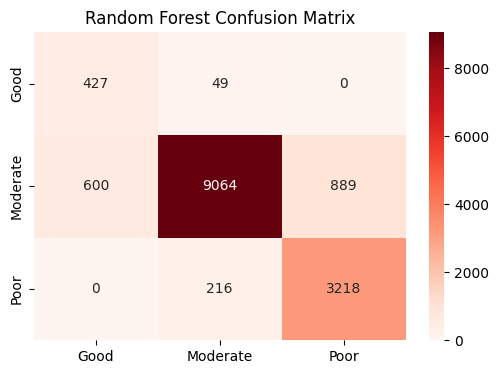

In [ ]:
# 5. Visualize
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Reds',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Random Forest Confusion Matrix')
plt.show()

# Stacking Ensemble


In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# 1. Define the Base Learners (The 6 models we trained earlier)
# We group our diverse models to act as "consultants"
# Note: probability=True is required for SVM to work within a Stacking Classifier
base_models = [
    ('lr', lr_model),                                     # Logistic Regression (Statistical Baseline)
    ('knn', knn_model),                                   # k-Nearest Neighbors (Distance-based)
    ('svm', svm_model),                                   # SVM (Boundary-based)
    ('dt', dt_model),                                     # Decision Tree (Rule-based)
    ('rf', rf_model)                                      # Random Forest (Ensemble-based)
]



In [ ]:
# 2. Initialize and Train Stacking
stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(),
    cv=5,
    n_jobs=-1
)
stacking_clf.fit(X_train_res, y_train_res)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('lr', ...), ('knn', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegression()
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",-1
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of

In [ ]:
# 3. Make predictions
y_pred_stack = stacking_clf.predict(X_test_scaled)

In [ ]:
# 4. Calculate Accuracies
stack_train_acc = stacking_clf.score(X_train_res, y_train_res)
stack_test_acc = stacking_clf.score(X_test_scaled, y_test)

In [ ]:
# 5. Print Metrics
print("--- Final Stacking Ensemble ---")
print(f"Training Accuracy: {stack_train_acc:.4f}")
print(f"Testing Accuracy: {stack_test_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_stack, target_names=le.classes_))

--- Final Stacking Ensemble ---
Training Accuracy: 0.9705
Testing Accuracy: 0.9038

Classification Report:
              precision    recall  f1-score   support

        Good       0.54      0.76      0.63       476
    Moderate       0.96      0.91      0.93     10553
        Poor       0.83      0.91      0.86      3434

    accuracy                           0.90     14463
   macro avg       0.78      0.86      0.81     14463
weighted avg       0.91      0.90      0.91     14463



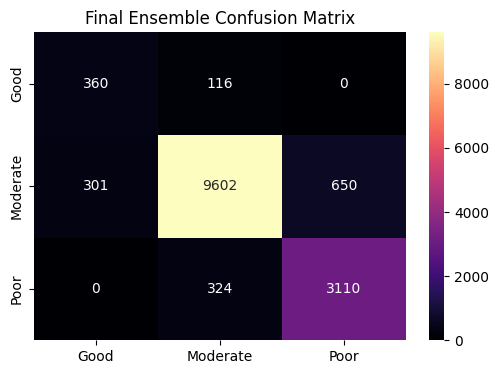

In [ ]:
# 6. Visualize
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_stack), annot=True, fmt='d', cmap='magma',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Final Ensemble Confusion Matrix')
plt.show()

In [ ]:
# =================================================================
# PRINT PRE-CALCULATED ACCURACIES DIRECTLY
# =================================================================

# Create a dictionary using your already executed and saved variables
accuracy_summary = {
    "Logistic Regression": (lr_train_acc, lr_test_acc),
    "k-Nearest Neighbors": (knn_train_acc, knn_test_acc),
    "Support Vector Machine": (svm_train_acc, svm_test_acc),
    "Decision Tree": (dt_train_acc, dt_test_acc),
    "Random Forest": (rf_train_acc, rf_test_acc),
    "Final Stacking Ensemble": (stack_train_acc, stack_test_acc)
}

# Print the comparison table headers
print("=" * 65)
print(f"{'Model Name':<25} | {'Train Accuracy':<15} | {'Test Accuracy':<15}")
print("=" * 65)

# Loop through the summary dictionary and display the scores directly
for model_name, (train_acc, test_acc) in accuracy_summary.items():
    print(f"{model_name:<25} | {train_acc:>14.4f} | {test_acc:>14.4f}")

print("=" * 65)

Model Name                | Train Accuracy  | Test Accuracy  
Logistic Regression       |         0.8831 |         0.8289
k-Nearest Neighbors       |         0.9445 |         0.8479
Support Vector Machine    |         0.9169 |         0.8538
Decision Tree             |         0.9151 |         0.8480
Random Forest             |         0.9484 |         0.8787
Final Stacking Ensemble   |         0.9705 |         0.9038


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.calibration import CalibratedClassifierCV
from imblearn.over_sampling import SMOTE

st.set_page_config(page_title="Cairo AQI Predictor", layout="wide")

st.markdown("""
<style>
.stApp { background: #0f172a; color: white; }
h1, h2, h3 { color: #00e5ff; }
[data-testid="metric-container"] {
    background: #1e293b;
    padding: 20px;
    border-radius: 15px;
    box-shadow: 0px 0px 12px rgba(0,255,255,.2);
}
section[data-testid="stSidebar"] { background: #111827; }
</style>
""", unsafe_allow_html=True)

st.title("Cairo Air Quality Index (AQI) Predictor")
st.markdown("""
### Project Overview
**Goal:** Predict Cairo Air Quality Class (Good / Moderate / Poor) using ML.

**Models:** Logistic Regression · KNN · SVM · Decision Tree · Random Forest · Stacking Ensemble
""")


@st.cache_data
def load_data():
    lat, lon = 30.0444, 31.2357
    start, end = "2018-01-01", "2026-04-01"
    aq_params = "pm10,pm2_5,nitrogen_dioxide"
    weather_params = "temperature_2m,relative_humidity_2m,wind_speed_10m,precipitation"
    tz = "Africa/Cairo"

    aq_url = (f"https://air-quality-api.open-meteo.com/v1/air-quality"
              f"?latitude={lat}&longitude={lon}&hourly={aq_params}"
              f"&start_date={start}&end_date={end}&timezone={tz}")
    w_url  = (f"https://archive-api.open-meteo.com/v1/archive"
              f"?latitude={lat}&longitude={lon}&start_date={start}&end_date={end}"
              f"&hourly={weather_params}&timezone={tz}")

    df_aq = pd.DataFrame(requests.get(aq_url).json()["hourly"])
    df_w  = pd.DataFrame(requests.get(w_url).json()["hourly"])
    df = pd.merge(df_aq, df_w, on="time")

    def get_aqi_class(pm25):
        if pm25 <= 12.0:   return "Good"
        elif pm25 <= 35.4: return "Moderate"
        else:              return "Poor"

    df["AQI_Class"] = df["pm2_5"].apply(get_aqi_class)
    df["time"] = pd.to_datetime(df["time"])
    df["year"] = df["time"].dt.year
    df["day_of_week"] = df["time"].dt.dayofweek
    df["is_weekend"] = df["day_of_week"].isin([4, 5]).astype(int)
    df = df.drop(columns=["pm2_5", "time", "day_of_week"])
    df = df.drop_duplicates()
    return df


df = load_data()


@st.cache_resource
def train_models(df):
    le = LabelEncoder()
    df2 = df.copy()
    df2["AQI_Class"] = le.fit_transform(df2["AQI_Class"])
    X = df2.drop(columns=["AQI_Class"])
    y = df2["AQI_Class"]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_train)
    X_te_sc = scaler.transform(X_test)

    smote = SMOTE(random_state=42)
    X_res, y_res = smote.fit_resample(X_tr_sc, y_train)

    lr  = LogisticRegression(max_iter=1000, random_state=42).fit(X_res, y_res)
    knn = KNeighborsClassifier(n_neighbors=10, n_jobs=-1).fit(X_res, y_res)
    svm = CalibratedClassifierCV(LinearSVC(max_iter=1000, random_state=42), cv=2).fit(X_res, y_res)
    dt  = DecisionTreeClassifier(max_depth=8, random_state=42).fit(X_res, y_res)
    rf  = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1).fit(X_res, y_res)

    base = [("lr", lr), ("dt", dt), ("rf", rf)]
    stack = StackingClassifier(
        estimators=base,
        final_estimator=LogisticRegression(),
        cv=2,
        n_jobs=-1
    ).fit(X_res, y_res)

    model_map = {
        "Logistic Regression": lr,
        "k-NN": knn,
        "SVM": svm,
        "Decision Tree": dt,
        "Random Forest": rf,
        "Stacking Ensemble": stack,
    }
    preds = {n: m.predict(X_te_sc) for n, m in model_map.items()}
    accs  = {n: (m.score(X_res, y_res), m.score(X_te_sc, y_test))
             for n, m in model_map.items()}
    return model_map, preds, accs, scaler, le, X, X_test, y_test, X.columns.tolist()


with st.spinner("Training all 6 models — please wait ~1 minute..."):
    models, preds, accs, scaler, le, X, X_test, y_test, feature_cols = train_models(df)


# Sidebar
st.sidebar.header("Live AQI Prediction")
st.sidebar.write(f"Rows: {df.shape[0]:,}  |  Features: {len(feature_cols)}")

st.sidebar.markdown("---")
st.sidebar.markdown("### Key Feature")
pm25_input = st.sidebar.number_input(
    "pm2_5 (µg/m³)  ⭐ Most Important",
    min_value=0.0, value=20.0, step=0.1,
    help="PM2.5 is the primary factor for AQI classification"
)

# Show what AQI class pm2_5 maps to
if pm25_input <= 12.0:
    pm25_label = "🟢 Good"
elif pm25_input <= 35.4:
    pm25_label = "🟡 Moderate"
else:
    pm25_label = "🔴 Poor"
st.sidebar.info(f"PM2.5 → AQI: **{pm25_label}**")

st.sidebar.markdown("---")
st.sidebar.markdown("### Other Features")
input_data = {}
for col in feature_cols:
    input_data[col] = st.sidebar.number_input(col, value=float(df[col].median()))

chosen_model = st.sidebar.selectbox("Model", list(models.keys()))
if st.sidebar.button("Predict AQI"):
    pred_arr = models[chosen_model].predict(
        scaler.transform(pd.DataFrame([input_data]))
    )
    label = le.inverse_transform(pred_arr)[0]
    icon = {"Good": "🟢", "Moderate": "🟡", "Poor": "🔴"}.get(label, "")
    st.sidebar.success(f"Model Prediction: {icon} **{label}**")
    st.sidebar.caption("Note: PM2.5 directly determines AQI class (see above)")


# Tabs
tab1, tab2, tab3 = st.tabs(["Model Performance", "Analysis", "Dataset"])

with tab1:
    st.subheader("Accuracy Comparison")
    rows = [{"Model": n, "Train Accuracy": f"{tr:.4f}", "Test Accuracy": f"{te:.4f}"}
            for n, (tr, te) in accs.items()]
    st.dataframe(pd.DataFrame(rows).set_index("Model"), use_container_width=True)

    st.subheader("Confusion Matrix")
    sel = st.selectbox("Select model", list(models.keys()))
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_test, preds[sel]), annot=True, fmt="d",
                cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
    ax.set_title(f"{sel} – Confusion Matrix")
    st.pyplot(fig)

with tab2:
    st.subheader("Feature Correlation Heatmap")
    fig2, ax2 = plt.subplots(figsize=(10, 7))
    sns.heatmap(df.select_dtypes(include=[np.number]).corr(),
                annot=True, cmap="coolwarm", fmt=".2f", ax=ax2)
    st.pyplot(fig2)

    st.subheader("AQI Class Distribution")
    fig3, ax3 = plt.subplots()
    sns.countplot(x="AQI_Class", data=df, palette="viridis",
                  order=["Good", "Moderate", "Poor"], ax=ax3)
    st.pyplot(fig3)

    st.subheader("PM10 Levels: Weekday vs Weekend")
    fig4, ax4 = plt.subplots()
    sns.barplot(x="is_weekend", y="pm10", data=df, palette="Set2", ax=ax4)
    ax4.set_xticks([0, 1])
    ax4.set_xticklabels(["Weekday", "Weekend"])
    st.pyplot(fig4)

with tab3:
    st.subheader("Dataset Preview")
    st.dataframe(df.head(50))
    st.download_button("Download CSV", df.to_csv(index=False),
                       "cairo_aqi_data.csv", "text/csv")


Overwriting app.py


In [ ]:
!pip install streamlit -q

import subprocess, threading, time

def run_streamlit():
    subprocess.Popen(['streamlit', 'run', 'app.py',
                      '--server.port=8501', '--server.headless=true'])

t = threading.Thread(target=run_streamlit)
t.start()
time.sleep(5)

# Use localhost.run — no account needed
tunnel = subprocess.Popen(
    ['ssh', '-o', 'StrictHostKeyChecking=no', '-R', '80:localhost:8501',
     'nokey@localhost.run'],
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT
)

# Print ALL output so we can see the URL
print('Waiting for tunnel URL...')
for line in tunnel.stdout:
    line = line.decode('utf-8').strip()
    if line:
        print(line)


Waiting for tunnel URL...
Pseudo-terminal will not be allocated because stdin is not a terminal.
Welcome to localhost.run!
Follow your favourite reverse tunnel at [https://twitter.com/localhost_run].
To set up and manage custom domains go to https://admin.localhost.run/
More details on custom domains (and how to enable subdomains of your custom
domain) at https://localhost.run/docs/custom-domains
If you get a permission denied error check the faq for how to connect with a key or
create a free tunnel without a key at [http://localhost:3000/docs/faq#generating-an-ssh-key].
To explore using localhost.run visit the documentation site:
https://localhost.run/docs/
** your connection id is 03f9cc7d-4432-4f7b-a610-113a89600e34, please mention it if you send me a message about an issue. **
authenticated as anonymous user
e8d09de6862499.lhr.life tunneled with tls termination, https://e8d09de6862499.lhr.life
create an account and add your key for a longer lasting domain name. see https://localhos